# Week 3: LSTM Deep Learning Model

Project: Automated Detection of Cyberbullying and Toxic Behavior in Social Networks

This notebook implements a deep learning model for multi-label toxic comment classification using PyTorch.

In [3]:
# 1. Install and Import Libraries

!pip install datasets -q

import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("results", exist_ok=True)

Device: cpu


In [4]:
# 2. Load Dataset

dataset = load_dataset("m375zhan/modified_jigsaw_toxic_comment_classification_challenge")
print(dataset)

df = dataset["train"].to_pandas()
print("Dataset shape:", df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/527 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/43.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
})
Dataset shape: (159571, 8)


,id,text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
# 3. Define Columns and Check Missing Values

TEXT_COLUMN = "text"

target_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

required_columns = [TEXT_COLUMN] + target_columns

print("Columns:")
print(df.columns)

print("\nMissing values:")
print(df[required_columns].isnull().sum())

df = df.dropna(subset=[TEXT_COLUMN]).reset_index(drop=True)

print("\nDataset shape after dropping missing text:", df.shape)

Columns:
Index(['id', 'text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='object')

Missing values:
text             0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Dataset shape after dropping missing text: (159571, 8)


In [6]:
# 4. Text Cleaning

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i m se...
2,"Hey man, I'm really not trying to edit war. It...",hey man i m really not trying to edit war it s...
3,"""\nMore\nI can't make any real suggestions on ...",more i can t make any real suggestions on impr...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...


In [15]:
# 5. Train / Validation / Test Split

X = df["clean_text"].values
y = df[target_columns].values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

# Use smaller dataset to make training faster
X_train = X_train[:30000]
y_train = y_train[:30000]

X_val = X_val[:5000]
y_val = y_val[:5000]

print("Reduced Train size:", len(X_train))
print("Reduced Validation size:", len(X_val))

Train size: 127656
Validation size: 15957
Test size: 15958
Reduced Train size: 30000
Reduced Validation size: 5000


In [16]:
# 6. Build Vocabulary

MAX_VOCAB_SIZE = 30000
MAX_LEN = 200

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

counter = Counter()

for text in X_train:
    counter.update(text.split())

most_common_words = counter.most_common(MAX_VOCAB_SIZE - 2)

word2idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, _ in most_common_words:
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

VOCAB_SIZE = len(word2idx)

print("Vocabulary size:", VOCAB_SIZE)
print("Most common words:", most_common_words[:10])

Vocabulary size: 30000
Most common words: [('the', 94616), ('to', 57095), ('i', 46148), ('and', 43188), ('of', 42368), ('you', 41134), ('a', 40688), ('is', 33863), ('that', 30977), ('it', 28414)]


In [17]:
# 7. Encode and Pad Text

def encode_text(text, word2idx, max_len):
    tokens = text.split()
    ids = [word2idx.get(token, word2idx[UNK_TOKEN]) for token in tokens]

    if len(ids) < max_len:
        ids = ids + [word2idx[PAD_TOKEN]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

X_train_encoded = np.array([encode_text(text, word2idx, MAX_LEN) for text in X_train])
X_val_encoded = np.array([encode_text(text, word2idx, MAX_LEN) for text in X_val])
X_test_encoded = np.array([encode_text(text, word2idx, MAX_LEN) for text in X_test])

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_val_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded train shape: (30000, 200)
Encoded validation shape: (5000, 200)
Encoded test shape: (15958, 200)


In [18]:
# 8. PyTorch Dataset and DataLoader

class ToxicCommentsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

BATCH_SIZE = 64

train_dataset = ToxicCommentsDataset(X_train_encoded, y_train)
val_dataset = ToxicCommentsDataset(X_val_encoded, y_val)
test_dataset = ToxicCommentsDataset(X_test_encoded, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 469
Validation batches: 79
Test batches: 250


In [20]:
# 9. LSTM Model

class LSTMToxicClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, num_layers=1, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]
        dropped = self.dropout(last_hidden)
        logits = self.fc(dropped)
        return logits

EMBED_DIM = 128
HIDDEN_DIM = 128
OUTPUT_DIM = len(target_columns)
NUM_LAYERS = 1
PAD_IDX = word2idx[PAD_TOKEN]

model = LSTMToxicClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    pad_idx=PAD_IDX,
    num_layers=NUM_LAYERS,
    dropout=0.3
).to(device)

print(model)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

LSTMToxicClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)
Number of parameters: 3972870


In [21]:
# 10. Loss Function and Optimizer

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [22]:
# 11. Training and Evaluation Functions

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for texts, labels in dataloader:
        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(texts)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for texts, labels in dataloader:
            texts = texts.to(device)
            labels = labels.to(device)

            logits = model(texts)
            loss = criterion(logits, labels)
            total_loss += loss.item()

    return total_loss / len(dataloader)


def get_predictions(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in dataloader:
            texts = texts.to(device)
            logits = model(texts)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels.numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    return all_labels, all_probs

In [23]:
# 12. Train Model

EPOCHS = 5
history = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print("-" * 40)

history_df = pd.DataFrame(history)
history_df.to_csv("results/week3_training_history.csv", index=False)
history_df

Epoch 1/5
Train Loss: 0.1638
Val Loss:   0.1423
----------------------------------------
Epoch 2/5
Train Loss: 0.1447
Val Loss:   0.1420
----------------------------------------
Epoch 3/5
Train Loss: 0.1442
Val Loss:   0.1422
----------------------------------------
Epoch 4/5
Train Loss: 0.1391
Val Loss:   0.1081
----------------------------------------
Epoch 5/5
Train Loss: 0.0964
Val Loss:   0.0798
----------------------------------------


,epoch,train_loss,val_loss
0,1,0.163783,0.142284
1,2,0.144734,0.142005
2,3,0.144245,0.142202
3,4,0.139088,0.108070
4,5,0.096353,0.079756


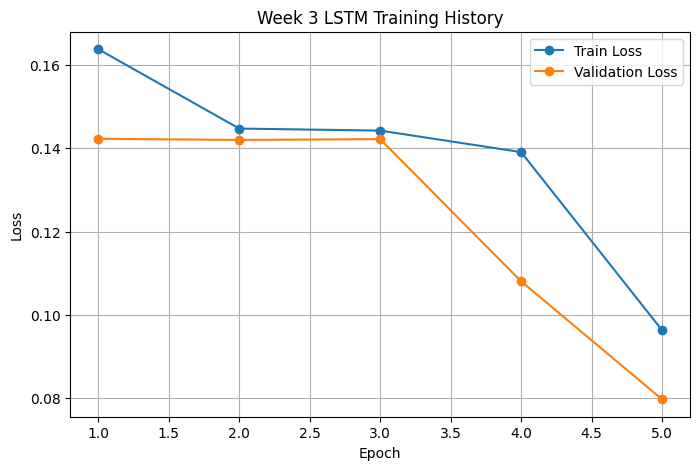

In [24]:
# 13. Plot Training History

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Week 3 LSTM Training History")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# 14. Validation Metrics

y_true, y_probs = get_predictions(model, val_loader, device)
y_pred = (y_probs >= 0.5).astype(int)

results = []

for i, label in enumerate(target_columns):
    try:
        roc_auc = roc_auc_score(y_true[:, i], y_probs[:, i])
    except ValueError:
        roc_auc = np.nan

    precision = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    recall = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    accuracy = accuracy_score(y_true[:, i], y_pred[:, i])

    results.append({
        "label": label,
        "roc_auc": roc_auc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "accuracy": accuracy
    })

results_df = pd.DataFrame(results)

print("Validation Results:")
display(results_df)

print("\nAverage Results:")
display(results_df[["roc_auc", "precision", "recall", "f1_score", "accuracy"]].mean())

results_df.to_csv("results/week3_lstm_validation_results.csv", index=False)

Validation Results:


,label,roc_auc,precision,recall,f1_score,accuracy
0,toxic,0.883729,0.815068,0.486708,0.609475,0.9390
1,severe_toxic,0.974603,0.000000,0.000000,0.000000,0.9896
2,obscene,0.946667,0.774510,0.612403,0.683983,0.9708
3,threat,0.884189,0.000000,0.000000,0.000000,0.9976
4,insult,0.928162,0.737705,0.535714,0.620690,0.9670
5,identity_hate,0.889334,0.000000,0.000000,0.000000,0.9908



Average Results:


,0
roc_auc,0.917781
precision,0.387881
recall,0.272471
f1_score,0.319025
accuracy,0.975800


In [26]:
# 15. Compare with Week 2 Baseline Manually

week2_average = {
    "roc_auc": 0.9147,
    "precision": 0.6766,
    "recall": 0.1809,
    "f1_score": 0.2621,
    "accuracy": 0.9744
}

week3_average = results_df[["roc_auc", "precision", "recall", "f1_score", "accuracy"]].mean().to_dict()

comparison_df = pd.DataFrame([
    {"model": "Week 2 TF-IDF + Naive Bayes", **week2_average},
    {"model": "Week 3 LSTM", **week3_average}
])

comparison_df.to_csv("results/week2_vs_week3_comparison.csv", index=False)
comparison_df

,model,roc_auc,precision,recall,f1_score,accuracy
0,Week 2 TF-IDF + Naive Bayes,0.914700,0.676600,0.180900,0.262100,0.9744
1,Week 3 LSTM,0.917781,0.387881,0.272471,0.319025,0.9758


In [27]:
# 16. Save Model

torch.save({
    "model_state_dict": model.state_dict(),
    "word2idx": word2idx,
    "target_columns": target_columns,
    "max_len": MAX_LEN
}, "results/week3_lstm_model.pt")

print("Model saved to results/week3_lstm_model.pt")

Model saved to results/week3_lstm_model.pt
